In [ ]:
#import libraries and init functions
%matplotlib widget

import sys
import numpy as np
import matplotlib.pyplot as plt
import magpylib as magpy

from scipy.spatial.transform import Rotation as R

from atomsmltr.environment import PlaneWaveLaserBeam
from atomsmltr.environment import GaussianLaserBeam
from atomsmltr.environment import ConstantForce
from atomsmltr.atoms import Ytterbium
from atomsmltr.simulation import Configuration, RK4
from atomsmltr.environment import (
    Vertical,
    Horizontal,
    CircularLeft,
    CircularRight,
    Linear,
    Vector,
)
from atomsmltr.environment.fields.magnetic.magpylib import MagpylibWrapper

def mot3d_coil(I=35, config="AH", plot_obj=False):

    if config=="H":
        curr_up = -I
        curr_down = -I
    else:
        if config=="AH":
            curr_up = I
            curr_down = -I
        else:
            raise ValueError("Invalid 3D MOT Coil Configuration")

    # Turns
    T = 3
    # Windings
    W = 2

    # Spacing between windings
    s = 1.37 * 0.001 # in mm

    # Diameter
    # d - Inner diameter
    d = 66.167 * 0.001 # in mm

    # Error
    e = 0 # in mm

    # Position of coils
    z_1 = 17.78 * 0.001 + e
    z_2 = -z_1

    coil = magpy.Collection()

    # Note: Unlike the cavity coil function, the 3D MOT function starts populating turns from the bottom of the top coil, and the top of the bottom coil.

    for i in range(0, T):
        for n in range(W):

            # Upper Coils
            winding1 = magpy.current.Circle(
                current = curr_up,
                diameter = d + (2*n + 1) * s,
                position = (0, 0, z_1 + i*s),
            )

            coil.add(winding1)

            # Lower Coils
            winding2 = magpy.current.Circle(
                current = curr_down,
                diameter = d + (2*n + 1) * s,
                position = (0, 0, z_2 - i*s),
            )

            coil.add(winding2)

    if plot_obj:
        coil.show(backend='plotly')

    return coil


Vertical push beam only to see how it counteracts gravity

In [2]:
# Fixed setup
# ------------- Atom
atom = Ytterbium()

main = atom.trans["main"]
inter = atom.trans["intercombination"]

# ------------- Gravity
m = Ytterbium().mass
g = 9.81
gravity = ConstantForce(field_value = (0, 0, -m*g), tag="gravity")

# ------------- Green Push beam
las1 = GaussianLaserBeam(
    wavelength=inter.wavelength,
    waist = 2e-3,
    waist_position = (0,0,-2),
    direction = (0,0,1)
)

las1.set_power_from_I(inter.Isat)
las1.polarization = Vertical()
las1.tag = "las1"

# ------------- Configuration
config = Configuration()
config.atom = atom
config += las1, gravity

C:\Users\zhang\AppData\Local\Temp\ipykernel_14316\3278330311.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


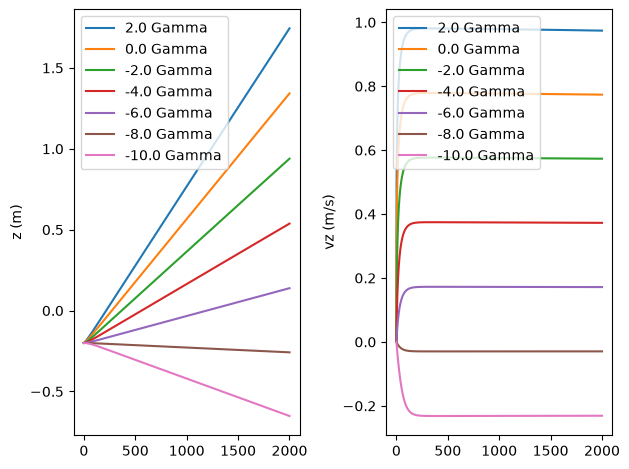

In [ ]:
#Sweeping parameters and plotting
detuningList = [2, 0, -2, -4, -6, -8, -10]
detuningList = [d * inter.Gamma for d in detuningList]

fig, ax = plt.subplots(1,2, tight_layout = True)

for detuning in detuningList:
    
    # # Set a red-detuning relative to the intercombination transition
    detuning_push = detuning
    config.add_atomlight_coupling("las1", "intercombination", detuning_push, override=True) # Arguments: laser = "las1", transition = intercombination", detuning = detuning_push


    # - simulation
    sim = RK4(config=config)
    t = np.linspace(0, 2, 6000) # timesteps for integration
    u0 = (0, 0, -0.2, 0, 0, 0) # atom starts with z = -0.2 m (20 cm below the 3D MOT center) and zero velocity
    res= sim.integrate(u0, t)

    # ------------ Plotting
    ax[0].plot(res.t * 1e3, res.y[2], label=str(detuning/inter.Gamma) + " Gamma")
    ax[0].set_ylabel("z (m)")
    ax[1].plot(res.t * 1e3, res.y[5], label=str(detuning/inter.Gamma) + " Gamma")
    ax[1].set_ylabel("vz (m/s)")

ax[0].legend()
ax[1].legend()
fig.show()

Push beam + z axis MOT lasers + gravity. See if we still can push the beam up.

Sweeping push beam detuning first

In [12]:
# Fixed setup
# ------------- Atom
atom = Ytterbium()

main = atom.trans["main"]
inter = atom.trans["intercombination"]

# ------------- Gravity
m = Ytterbium().mass
g = 9.81
gravity = ConstantForce(field_value = (0, 0, -m*g), tag="gravity")

# ------------- Green Push beam
las1 = GaussianLaserBeam(
    wavelength=inter.wavelength,
    waist = 2e-3,
    waist_position = (0,0,-2),
    direction = (0,0,1)
)

las1.set_power_from_I(inter.Isat)
las1.polarization = Vertical()
las1.tag = "las1"

#------------------------------------------ 3D MOT lasers setup ------------------------------------------#

# Create the 6 beams for a 3D MOT
# 1 & 2: Vertical Pair (+z, -z)
las_z_up = GaussianLaserBeam(wavelength=inter.wavelength, waist=6e-3, waist_position=(0, 0, 0), direction=(0,0,1))
las_z_down = GaussianLaserBeam(wavelength=inter.wavelength, waist=6e-3, waist_position=(0, 0, 0), direction=(0,0,-1))

# Set power (can increase if we want power broadening)
las_z_up.set_power_from_I(5 * inter.Isat)
las_z_down.set_power_from_I(5 * inter.Isat)


# Assign Polarizations (Must be Circular and match the anti-Helmholtz field signs!)
las_z_up.polarization = CircularRight()
las_z_down.polarization = CircularRight()


# Tag them for coupling identification
las_z_up.tag = "z_up"; las_z_down.tag = "z_down"


# ------------- Configuration
config = Configuration()
config.atom = atom
config += las1, gravity, las_z_up, las_z_down

# Tie all 6 lasers to the intercombination transition simultaneously
detuning_3D_mot = -inter.Gamma/2 # red-detuning for trapping
for tag in ["z_up", "z_down"]:
    config.add_atomlight_coupling(tag, "intercombination", detuning_3D_mot)

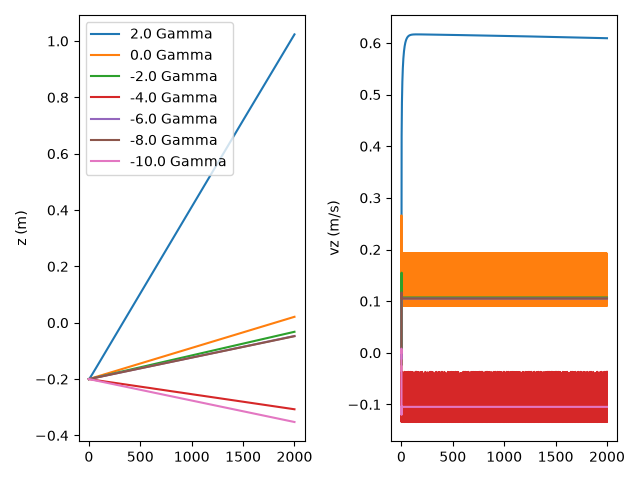

In [13]:
#Sweeping push beam detuning
detuningList = [2, 0, -2, -4, -6, -8, -10]
detuningList = [d * inter.Gamma for d in detuningList]

fig, ax = plt.subplots(1,2, tight_layout = True)

for detuning in detuningList:
    
    # # Set a red-detuning relative to the intercombination transition
    detuning_push = detuning
    config.add_atomlight_coupling("las1", "intercombination", detuning_push, override=True) # Arguments: laser = "las1", transition = intercombination", detuning = detuning_push


    # - simulation
    sim = RK4(config=config)
    t = np.linspace(0, 2, 6000) # timesteps for integration
    u0 = (0, 0, -0.2, 0, 0, 0) # atom starts with z = -0.2 m (20 cm below the 3D MOT center) and zero velocity
    res= sim.integrate(u0, t)

    # ------------ Plotting
    ax[0].plot(res.t * 1e3, res.y[2], label=str(detuning/inter.Gamma) + " Gamma")
    ax[0].set_ylabel("z (m)")
    ax[1].plot(res.t * 1e3, res.y[5], label=str(detuning/inter.Gamma) + " Gamma")
    ax[1].set_ylabel("vz (m/s)")

ax[0].legend()
plt.show()

Push + z MOT laser + grav

sweep MOT laser intensity

In [8]:
# Fixed setup
# ------------- Atom
atom = Ytterbium()

main = atom.trans["main"]
inter = atom.trans["intercombination"]

# ------------- Gravity
m = Ytterbium().mass
g = 9.81
gravity = ConstantForce(field_value = (0, 0, -m*g), tag="gravity")

# ------------- Green Push beam
las1 = GaussianLaserBeam(
    wavelength=inter.wavelength,
    waist = 2e-3,
    waist_position = (0,0,-2),
    direction = (0,0,1)
)

las1.set_power_from_I(inter.Isat)
las1.polarization = Vertical()
las1.tag = "las1"

#------------------------------------------ 3D MOT lasers setup ------------------------------------------#

# Create the 6 beams for a 3D MOT
# 1 & 2: Vertical Pair (+z, -z)
las_z_up = GaussianLaserBeam(wavelength=inter.wavelength, waist=6e-3, waist_position=(0, 0, 0), direction=(0,0,1))
las_z_down = GaussianLaserBeam(wavelength=inter.wavelength, waist=6e-3, waist_position=(0, 0, 0), direction=(0,0,-1))




# Assign Polarizations (Must be Circular and match the anti-Helmholtz field signs!)
las_z_up.polarization = CircularRight()
las_z_down.polarization = CircularRight()


# Tag them for coupling identification
las_z_up.tag = "z_up"; las_z_down.tag = "z_down"


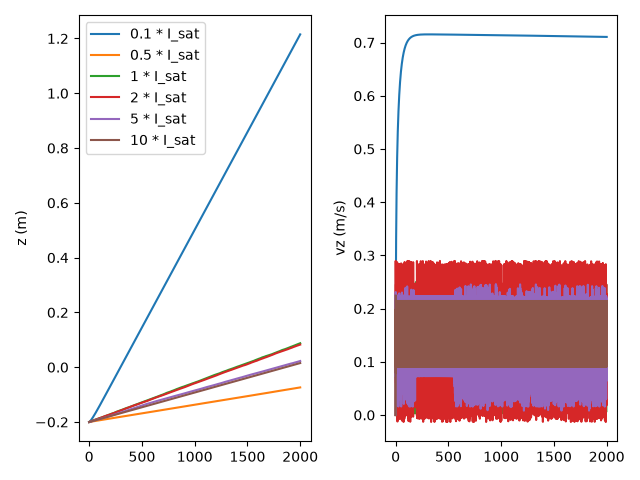

In [ ]:
#Sweeping MOT laser intensity

intensityList = [0.1, 0.5, 1, 2, 5, 10]
fig, ax = plt.subplots(1,2, tight_layout = True)

for intensity in intensityList:
    # Set power (can increase if we want power broadening)
    las_z_up.set_power_from_I(intensity * inter.Isat)
    las_z_down.set_power_from_I(intensity * inter.Isat)

    # ------------- Configuration
    config = Configuration()
    config.atom = atom
    config += las1, gravity, las_z_up, las_z_down

    # # Set a red-detuning relative to the intercombination transition
    detuning_push = -inter.Gamma # red-detuning for pushing
    config.add_atomlight_coupling("las1", "intercombination", detuning_push) # Arguments: laser = "las1", transition = intercombination", detuning = detuning_push


    # Tie all 6 lasers to the intercombination transition simultaneously
    detuning_3D_mot = -inter.Gamma/2 # red-detuning for trapping
    for tag in ["z_up", "z_down"]:
        config.add_atomlight_coupling(tag, "intercombination", detuning_3D_mot)

    # - simulation
    sim = RK4(config=config)
    t = np.linspace(0, 2, 6000) # timesteps for integration
    u0 = (0, 0, -0.2, 0, 0, 0) # atom starts with z = -0.2 m (20 cm below the 3D MOT center) and zero velocity
    res= sim.integrate(u0, t)

    # ------------ Plotting
    ax[0].plot(res.t * 1e3, res.y[2], label=str(intensity) + " * I_sat")
    ax[0].set_ylabel("z (m)")
    ax[1].plot(res.t * 1e3, res.y[5], label=str(intensity) + " * I_sat")
    ax[1].set_ylabel("vz (m/s)")

ax[0].legend()
plt.show()

The whole shebang

I have an inclination that changing the 3D MOT beam diameter won't change how the atom moves vertically (since we don't have diffusion). So the first thing I'll do is sweep the waist of the MOT lasers. 

In [33]:
#Fixed setup

#------------------------------------------ Atom setup ------------------------------------------#

atom = Ytterbium()
# get transition, to help setting up lasers
main = atom.trans["main"] # 399 nm transition to 1P1
intercombination = atom.trans["intercombination"] # 556 nm transition to 3P1

#------------------------------------------ Green push beam setup ------------------------------------------#

laser_1 = GaussianLaserBeam(
    wavelength=intercombination.wavelength,
    waist=2e-3,
    waist_position=(0, 0, -0.2),
    direction=(0, 0, 1),
)

laser_1.set_power_from_I(intercombination.Isat) # set power to reach Isat
laser_1.polarization = Vertical()
laser_1.tag = "las1"

#------------------------------------------ 2D MOT B-field setup ------------------------------------------#

Br = 1.42  # Tesla
mu0 = 4*np.pi*1e-7
M = Br / mu0

magnet_1 = magpy.magnet.Cuboid(
    position = (-5.3*0.01, -4*0.01, 0), dimension = (2*0.01, 2*0.01, 5.5*0.01), magnetization = (0, 0, M))
magnet_2 = magpy.magnet.Cuboid(
    position = (-5.3*0.01, 4*0.01, 0), dimension = (2*0.01, 2*0.01, 5.5*0.01), magnetization = (0, 0, M))
magnet_3 = magpy.magnet.Cuboid(
    position = (5.3*0.01, -4*0.01, 0), dimension = (2*0.01, 2*0.01, 5.5*0.01), magnetization = (0, 0, -M))
magnet_4 = magpy.magnet.Cuboid(
    position = (5.3*0.01, 4*0.01, 0), dimension = (2*0.01, 2*0.01, 5.5*0.01), magnetization = (0, 0, -M))

magnets = magpy.Collection(magnet_1, magnet_2, magnet_3, magnet_4)

# Rotate so the extraction axis points UP (+z)
rot = R.from_euler('x', 90, degrees=True)
magnets.rotate(rot, anchor=(0, 0, 0))

# Shift the whole 2D MOT assembly 20 cm below the 3D MOT chamber center
magnets.move((0, 0, -0.2))

# wrap it up
mag_field_2D_MOT = MagpylibWrapper(magnets)
mag_field_2D_MOT.tag = "2D MOT coils"

#magnets.show(backend='plotly')

#------------------------------------------ 3D MOT B-field setup ------------------------------------------#

motcoil = mot3d_coil(config="AH", plot_obj=False)

# ROTATION: Rotate the 3D MOT coils if needed
# For example, rotating 90 degrees around the X-axis 
# (This would flip the coil symmetry axis from the Z-axis to the Y-axis)
rot_3d_mot = R.from_euler('x', 90, degrees=True)
motcoil.rotate(rot_3d_mot, anchor=(0, 0, 0))

# wrap it up
mag_field_3D_MOT = MagpylibWrapper(motcoil)
mag_field_3D_MOT.tag = "3D MOT coils"

#------------------------------------------ Gravity ------------------------------------------#

m = Ytterbium().mass  # kg
g = 9.81  # m/s^2
grav_force = (0, 0, -m*g)
gravity = ConstantForce(field_value=grav_force, tag="gravity")

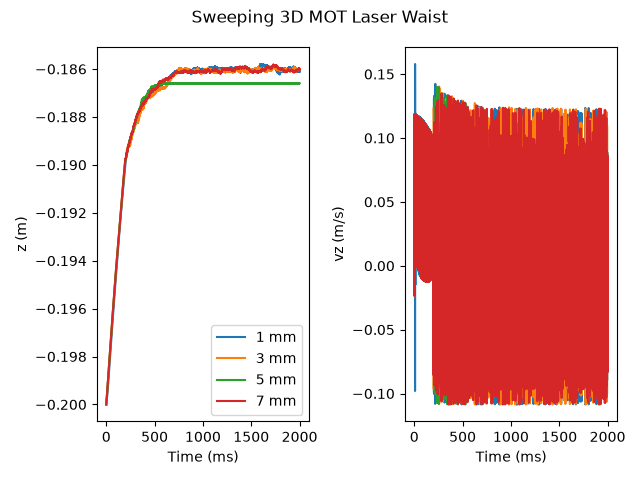

In [34]:
waistList = [1,3,5,7]

fig, ax = plt.subplots(1,2, tight_layout = True)

for waist in waistList:
    #------------------------------------------ 3D MOT lasers setup ------------------------------------------#

    # Create the 6 beams for a 3D MOT
    # 1 & 2: Vertical Pair (+z, -z)
    las_z_up = GaussianLaserBeam(wavelength=intercombination.wavelength, waist=waist * 1e-3, waist_position=(0, 0, 0), direction=(0,0,1))
    las_z_down = GaussianLaserBeam(wavelength=intercombination.wavelength, waist=waist * 1e-3, waist_position=(0, 0, 0), direction=(0,0,-1))

    # 3 & 4: Horizontal Pair 1 (+x, -x)
    las_x_plus = GaussianLaserBeam(wavelength=intercombination.wavelength, waist=waist * 1e-3, waist_position=(0, 0, 0), direction=(1,0,0))
    las_x_minus = GaussianLaserBeam(wavelength=intercombination.wavelength, waist=waist * 1e-3, waist_position=(0, 0, 0), direction=(-1,0,0))

    # 5 & 6: Horizontal Pair 2 (+y, -y)
    las_y_plus = GaussianLaserBeam(wavelength=intercombination.wavelength, waist=waist * 1e-3, waist_position=(0, 0, 0), direction=(0,1,0))
    las_y_minus = GaussianLaserBeam(wavelength=intercombination.wavelength, waist=waist * 1e-3, waist_position=(0, 0, 0), direction=(0,-1,0))

    # Set power (can increase if we want power broadening)
    las_z_up.set_power_from_I(2 * intercombination.Isat)
    las_z_down.set_power_from_I(2 * intercombination.Isat)
    las_x_plus.set_power_from_I(2 * intercombination.Isat)
    las_x_minus.set_power_from_I(2 * intercombination.Isat)
    las_y_plus.set_power_from_I(2 * intercombination.Isat)
    las_y_minus.set_power_from_I(2 * intercombination.Isat)

    # Assign Polarizations (Must be Circular and match the anti-Helmholtz field signs!)
    las_z_up.polarization = CircularRight()
    las_z_down.polarization = CircularRight()
    las_x_plus.polarization = CircularRight()
    las_x_minus.polarization = CircularRight()
    las_y_plus.polarization = CircularLeft()
    las_y_minus.polarization = CircularLeft()

    # Tag them for coupling identification
    las_z_up.tag = "z_up"; las_z_down.tag = "z_down"
    las_x_plus.tag = "x_plus"; las_x_minus.tag = "x_minus"
    las_y_plus.tag = "y_plus"; las_y_minus.tag = "y_minus"

    config = Configuration()
    config.atom = atom
    config += laser_1, gravity, mag_field_3D_MOT, mag_field_2D_MOT
    config += las_z_up, las_z_down, las_x_plus, las_x_minus, las_y_plus, las_y_minus

    # # Set a red-detuning relative to the intercombination transition
    detuning_push = -2*intercombination.Gamma  # red-detuning for pushing
    config.add_atomlight_coupling("las1", "intercombination", detuning_push) # Arguments: laser = "las1", transition = intercombination", detuning = detuning_push

    # Tie all 6 lasers to the intercombination transition simultaneously
    detuning_3D_mot = -intercombination.Gamma/2 # red-detuning for trapping
    for tag in ["z_up", "z_down", "x_plus", "x_minus", "y_plus", "y_minus"]:
        config.add_atomlight_coupling(tag, "intercombination", detuning_3D_mot)

    # - simulation
    sim = RK4(config=config)
    t = np.linspace(0, 2, 6000) # timesteps for integration
    u0 = (0, 0, -0.2, 0, 0, 0) # atom starts with vz=100m/s
    res = sim.integrate(u0, t)

        # ------------ Plotting
    ax[0].plot(res.t * 1e3, res.y[2], label=str(waist) + " mm")
    ax[0].set_ylabel("z (m)")
    ax[0].set_xlabel("Time (ms)")
    ax[1].plot(res.t * 1e3, res.y[5], label=str(waist) + " mm")
    ax[1].set_ylabel("vz (m/s)")
    ax[1].set_xlabel("Time (ms)")

ax[0].legend()
fig.suptitle("Sweeping 3D MOT Laser Waist")
plt.show()

I would say this result support that waist size does not matter significantly? I don't know why the 5mm case is slightly different from the other ones though.

The whole shebang

Now I want to play with the detuning of the push beam

In [36]:
# Fixed setup
#------------------------------------------ Atom setup ------------------------------------------#

atom = Ytterbium()
# get transition, to help setting up lasers
main = atom.trans["main"] # 399 nm transition to 1P1
intercombination = atom.trans["intercombination"] # 556 nm transition to 3P1

#------------------------------------------ Green push beam setup ------------------------------------------#

laser_1 = GaussianLaserBeam(
    wavelength=intercombination.wavelength,
    waist=2e-3,
    waist_position=(0, 0, -0.2),
    direction=(0, 0, 1),
)

laser_1.set_power_from_I(intercombination.Isat) # set power to reach Isat
laser_1.polarization = Vertical()
laser_1.tag = "las1"

#------------------------------------------ 2D MOT B-field setup ------------------------------------------#

Br = 1.42  # Tesla
mu0 = 4*np.pi*1e-7
M = Br / mu0

magnet_1 = magpy.magnet.Cuboid(
    position = (-5.3*0.01, -4*0.01, 0), dimension = (2*0.01, 2*0.01, 5.5*0.01), magnetization = (0, 0, M))
magnet_2 = magpy.magnet.Cuboid(
    position = (-5.3*0.01, 4*0.01, 0), dimension = (2*0.01, 2*0.01, 5.5*0.01), magnetization = (0, 0, M))
magnet_3 = magpy.magnet.Cuboid(
    position = (5.3*0.01, -4*0.01, 0), dimension = (2*0.01, 2*0.01, 5.5*0.01), magnetization = (0, 0, -M))
magnet_4 = magpy.magnet.Cuboid(
    position = (5.3*0.01, 4*0.01, 0), dimension = (2*0.01, 2*0.01, 5.5*0.01), magnetization = (0, 0, -M))

magnets = magpy.Collection(magnet_1, magnet_2, magnet_3, magnet_4)

# Rotate so the extraction axis points UP (+z)
rot = R.from_euler('x', 90, degrees=True)
magnets.rotate(rot, anchor=(0, 0, 0))

# Shift the whole 2D MOT assembly 20 cm below the 3D MOT chamber center
magnets.move((0, 0, -0.2))

# wrap it up
mag_field_2D_MOT = MagpylibWrapper(magnets)
mag_field_2D_MOT.tag = "2D MOT coils"

#magnets.show(backend='plotly')

#------------------------------------------ 3D MOT B-field setup ------------------------------------------#

motcoil = mot3d_coil(config="AH", plot_obj=False)

# ROTATION: Rotate the 3D MOT coils if needed
# For example, rotating 90 degrees around the X-axis 
# (This would flip the coil symmetry axis from the Z-axis to the Y-axis)
rot_3d_mot = R.from_euler('x', 90, degrees=True)
motcoil.rotate(rot_3d_mot, anchor=(0, 0, 0))

# wrap it up
mag_field_3D_MOT = MagpylibWrapper(motcoil)
mag_field_3D_MOT.tag = "3D MOT coils"

#------------------------------------------ 3D MOT lasers setup ------------------------------------------#

# Create the 6 beams for a 3D MOT
# 1 & 2: Vertical Pair (+z, -z)
las_z_up = GaussianLaserBeam(wavelength=intercombination.wavelength, waist=7e-3, waist_position=(0, 0, 0), direction=(0,0,1))
las_z_down = GaussianLaserBeam(wavelength=intercombination.wavelength, waist=7e-3, waist_position=(0, 0, 0), direction=(0,0,-1))

# 3 & 4: Horizontal Pair 1 (+x, -x)
las_x_plus = GaussianLaserBeam(wavelength=intercombination.wavelength, waist=7e-3, waist_position=(0, 0, 0), direction=(1,0,0))
las_x_minus = GaussianLaserBeam(wavelength=intercombination.wavelength, waist=7e-3, waist_position=(0, 0, 0), direction=(-1,0,0))

# 5 & 6: Horizontal Pair 2 (+y, -y)
las_y_plus = GaussianLaserBeam(wavelength=intercombination.wavelength, waist=7e-3, waist_position=(0, 0, 0), direction=(0,1,0))
las_y_minus = GaussianLaserBeam(wavelength=intercombination.wavelength, waist=7e-3, waist_position=(0, 0, 0), direction=(0,-1,0))

# Set power (can increase if we want power broadening)
las_z_up.set_power_from_I(2 * intercombination.Isat)
las_z_down.set_power_from_I(2 * intercombination.Isat)
las_x_plus.set_power_from_I(2 * intercombination.Isat)
las_x_minus.set_power_from_I(2 * intercombination.Isat)
las_y_plus.set_power_from_I(2 * intercombination.Isat)
las_y_minus.set_power_from_I(2 * intercombination.Isat)


# Assign Polarizations (Must be Circular and match the anti-Helmholtz field signs!)
las_z_up.polarization = CircularRight()
las_z_down.polarization = CircularRight()
las_x_plus.polarization = CircularRight()
las_x_minus.polarization = CircularRight()
las_y_plus.polarization = CircularLeft()
las_y_minus.polarization = CircularLeft()

# Tag them for coupling identification
las_z_up.tag = "z_up"; las_z_down.tag = "z_down"
las_x_plus.tag = "x_plus"; las_x_minus.tag = "x_minus"
las_y_plus.tag = "y_plus"; las_y_minus.tag = "y_minus"

#------------------------------------------ Gravity ------------------------------------------#

m = Ytterbium().mass  # kg
g = 9.81  # m/s^2
grav_force = (0, 0, -m*g)
gravity = ConstantForce(field_value=grav_force, tag="gravity")


#------------------------------------------ config ------------------------------------------#

config = Configuration()
config.atom = atom
config += laser_1, gravity, mag_field_3D_MOT, mag_field_2D_MOT
config += las_z_up, las_z_down, las_x_plus, las_x_minus, las_y_plus, las_y_minus

# Tie all 6 lasers to the intercombination transition simultaneously
detuning_3D_mot = -intercombination.Gamma/2 # red-detuning for trapping
for tag in ["z_up", "z_down", "x_plus", "x_minus", "y_plus", "y_minus"]:
    config.add_atomlight_coupling(tag, "intercombination", detuning_3D_mot)

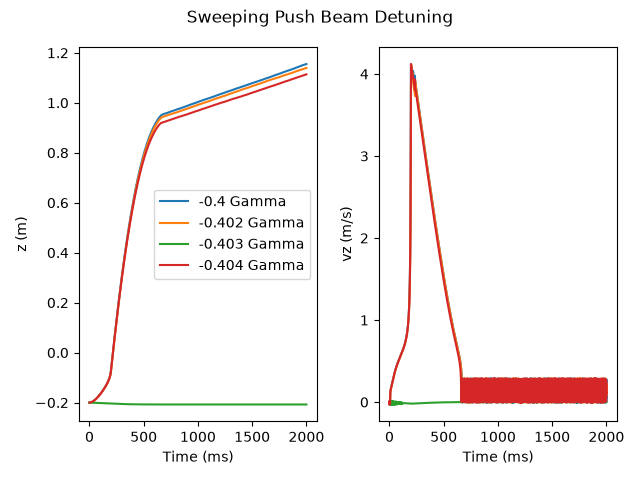

In [40]:
#Sweeping push beam detuning
detuningList = [-0.4,-0.402, -0.403 ,-0.404] # in units of Gamma

fig, ax = plt.subplots(1,2, tight_layout = True)

for detuning in detuningList:
    
    # # Set a red-detuning relative to the intercombination transition
    detuning_push = detuning * inter.Gamma
    config.add_atomlight_coupling("las1", "intercombination", detuning_push, override=True) # Arguments: laser = "las1", transition = intercombination", detuning = detuning_push


    # - simulation
    sim = RK4(config=config)
    t = np.linspace(0, 2, 6000) # timesteps for integration
    u0 = (0, 0, -0.2, 0, 0, 0) # atom starts with z = -0.2 m (20 cm below the 3D MOT center) and zero velocity
    res= sim.integrate(u0, t)

    # ------------ Plotting
    ax[0].plot(res.t * 1e3, res.y[2], label=str(detuning) + " Gamma")
    ax[0].set_ylabel("z (m)")
    ax[0].set_xlabel("Time (ms)")
    ax[1].plot(res.t * 1e3, res.y[5], label=str(detuning) + " Gamma")
    ax[1].set_ylabel("vz (m/s)")
    ax[1].set_xlabel("Time (ms)")
ax[0].legend()
fig.suptitle("Sweeping Push Beam Detuning")
plt.show()

Sweeping 3D MOT beam intensity

In [51]:
# Fixed setup
#------------------------------------------ Atom setup ------------------------------------------#

atom = Ytterbium()
# get transition, to help setting up lasers
main = atom.trans["main"] # 399 nm transition to 1P1
intercombination = atom.trans["intercombination"] # 556 nm transition to 3P1

#------------------------------------------ Green push beam setup ------------------------------------------#

laser_1 = GaussianLaserBeam(
    wavelength=intercombination.wavelength,
    waist=5e-3,
    waist_position=(0, 0, -0.2),
    direction=(0, 0, 1),
)

laser_1.set_power_from_I(3 *intercombination.Isat) # set power to reach Isat
laser_1.polarization = Vertical()
laser_1.tag = "las1"

#------------------------------------------ 2D MOT B-field setup ------------------------------------------#

Br = 1.42  # Tesla
mu0 = 4*np.pi*1e-7
M = Br / mu0

magnet_1 = magpy.magnet.Cuboid(
    position = (-5.3*0.01, -4*0.01, 0), dimension = (2*0.01, 2*0.01, 5.5*0.01), magnetization = (0, 0, M))
magnet_2 = magpy.magnet.Cuboid(
    position = (-5.3*0.01, 4*0.01, 0), dimension = (2*0.01, 2*0.01, 5.5*0.01), magnetization = (0, 0, M))
magnet_3 = magpy.magnet.Cuboid(
    position = (5.3*0.01, -4*0.01, 0), dimension = (2*0.01, 2*0.01, 5.5*0.01), magnetization = (0, 0, -M))
magnet_4 = magpy.magnet.Cuboid(
    position = (5.3*0.01, 4*0.01, 0), dimension = (2*0.01, 2*0.01, 5.5*0.01), magnetization = (0, 0, -M))

magnets = magpy.Collection(magnet_1, magnet_2, magnet_3, magnet_4)

# Rotate so the extraction axis points UP (+z)
rot = R.from_euler('x', 90, degrees=True)
magnets.rotate(rot, anchor=(0, 0, 0))

# Shift the whole 2D MOT assembly 20 cm below the 3D MOT chamber center
magnets.move((0, 0, -0.2))

# wrap it up
mag_field_2D_MOT = MagpylibWrapper(magnets)
mag_field_2D_MOT.tag = "2D MOT coils"

#magnets.show(backend='plotly')

#------------------------------------------ 3D MOT B-field setup ------------------------------------------#

motcoil = mot3d_coil(config="AH", plot_obj=False)

# ROTATION: Rotate the 3D MOT coils if needed
# For example, rotating 90 degrees around the X-axis 
# (This would flip the coil symmetry axis from the Z-axis to the Y-axis)
rot_3d_mot = R.from_euler('x', 90, degrees=True)
motcoil.rotate(rot_3d_mot, anchor=(0, 0, 0))

# wrap it up
mag_field_3D_MOT = MagpylibWrapper(motcoil)
mag_field_3D_MOT.tag = "3D MOT coils"

#------------------------------------------ 3D MOT lasers setup ------------------------------------------#

# Create the 6 beams for a 3D MOT
# 1 & 2: Vertical Pair (+z, -z)
las_z_up = GaussianLaserBeam(wavelength=intercombination.wavelength, waist=7.5e-3, waist_position=(0, 0, 0), direction=(0,0,1))
las_z_down = GaussianLaserBeam(wavelength=intercombination.wavelength, waist=7.5e-3, waist_position=(0, 0, 0), direction=(0,0,-1))

# 3 & 4: Horizontal Pair 1 (+x, -x)
las_x_plus = GaussianLaserBeam(wavelength=intercombination.wavelength, waist=7.5e-3, waist_position=(0, 0, 0), direction=(1,0,0))
las_x_minus = GaussianLaserBeam(wavelength=intercombination.wavelength, waist=7.5e-3, waist_position=(0, 0, 0), direction=(-1,0,0))

# 5 & 6: Horizontal Pair 2 (+y, -y)
las_y_plus = GaussianLaserBeam(wavelength=intercombination.wavelength, waist=7.5e-3, waist_position=(0, 0, 0), direction=(0,1,0))
las_y_minus = GaussianLaserBeam(wavelength=intercombination.wavelength, waist=7.5e-3, waist_position=(0, 0, 0), direction=(0,-1,0))

# Set power (can increase if we want power broadening)
las_z_up.set_power_from_I(10 * intercombination.Isat)
las_z_down.set_power_from_I(10 * intercombination.Isat)
las_x_plus.set_power_from_I(10 * intercombination.Isat)
las_x_minus.set_power_from_I(10 * intercombination.Isat)
las_y_plus.set_power_from_I(10 * intercombination.Isat)
las_y_minus.set_power_from_I(10 * intercombination.Isat)


# Assign Polarizations (Must be Circular and match the anti-Helmholtz field signs!)
las_z_up.polarization = CircularRight()
las_z_down.polarization = CircularRight()
las_x_plus.polarization = CircularRight()
las_x_minus.polarization = CircularRight()
las_y_plus.polarization = CircularLeft()
las_y_minus.polarization = CircularLeft()

# Tag them for coupling identification
las_z_up.tag = "z_up"; las_z_down.tag = "z_down"
las_x_plus.tag = "x_plus"; las_x_minus.tag = "x_minus"
las_y_plus.tag = "y_plus"; las_y_minus.tag = "y_minus"

#------------------------------------------ Gravity ------------------------------------------#

m = Ytterbium().mass  # kg
g = 9.81  # m/s^2
grav_force = (0, 0, -m*g)
gravity = ConstantForce(field_value=grav_force, tag="gravity")


#------------------------------------------ config ------------------------------------------#

config = Configuration()
config.atom = atom
config += laser_1, gravity, mag_field_3D_MOT, mag_field_2D_MOT
config += las_z_up, las_z_down, las_x_plus, las_x_minus, las_y_plus, las_y_minus

# Set a red-detuning relative to the intercombination transition
detuning_push = 0  # red-detuning for pushing
config.add_atomlight_coupling("las1", "intercombination", detuning_push) # Arguments: laser = "las1", transition = intercombination", detuning = detuning_push


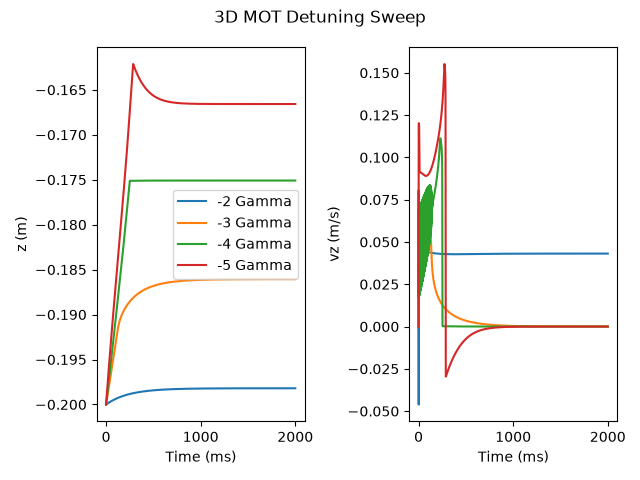

In [50]:
#Sweeping push beam detuning
detuningList = [-2,-3, -4 ,-5] # in units of Gamma

fig, ax = plt.subplots(1,2, tight_layout = True)

for detuning in detuningList:
    
    # Tie all 6 lasers to the intercombination transition simultaneously
    detuning_3D_mot = detuning * intercombination.Gamma
    for tag in ["z_up", "z_down", "x_plus", "x_minus", "y_plus", "y_minus"]:
        config.add_atomlight_coupling(tag, "intercombination", detuning_3D_mot, override=True)

    # - simulation
    sim = RK4(config=config)
    t = np.linspace(0, 2, 6000) # timesteps for integration
    u0 = (0, 0, -0.2, 0, 0, 0) # atom starts with z = -0.2 m (20 cm below the 3D MOT center) and zero velocity
    res= sim.integrate(u0, t)

    # ------------ Plotting
    ax[0].plot(res.t * 1e3, res.y[2], label=str(detuning) + " Gamma")
    ax[0].set_ylabel("z (m)")
    ax[0].set_xlabel("Time (ms)")
    ax[1].plot(res.t * 1e3, res.y[5], label=str(detuning) + " Gamma")
    ax[1].set_ylabel("vz (m/s)")
    ax[1].set_xlabel("Time (ms)")
ax[0].legend()
fig.suptitle("3D MOT Detuning Sweep")
plt.show()

Sweeping push beam intensity

In [52]:
# Fixed setup
#------------------------------------------ Atom setup ------------------------------------------#

atom = Ytterbium()
# get transition, to help setting up lasers
main = atom.trans["main"] # 399 nm transition to 1P1
intercombination = atom.trans["intercombination"] # 556 nm transition to 3P1

#------------------------------------------ Green push beam setup ------------------------------------------#

laser_1 = GaussianLaserBeam(
    wavelength=intercombination.wavelength,
    waist=5e-3,
    waist_position=(0, 0, -0.2),
    direction=(0, 0, 1),
)

laser_1.set_power_from_I(3 *intercombination.Isat) # set power to reach Isat
laser_1.polarization = Vertical()
laser_1.tag = "las1"

#------------------------------------------ 2D MOT B-field setup ------------------------------------------#

Br = 1.42  # Tesla
mu0 = 4*np.pi*1e-7
M = Br / mu0

magnet_1 = magpy.magnet.Cuboid(
    position = (-5.3*0.01, -4*0.01, 0), dimension = (2*0.01, 2*0.01, 5.5*0.01), magnetization = (0, 0, M))
magnet_2 = magpy.magnet.Cuboid(
    position = (-5.3*0.01, 4*0.01, 0), dimension = (2*0.01, 2*0.01, 5.5*0.01), magnetization = (0, 0, M))
magnet_3 = magpy.magnet.Cuboid(
    position = (5.3*0.01, -4*0.01, 0), dimension = (2*0.01, 2*0.01, 5.5*0.01), magnetization = (0, 0, -M))
magnet_4 = magpy.magnet.Cuboid(
    position = (5.3*0.01, 4*0.01, 0), dimension = (2*0.01, 2*0.01, 5.5*0.01), magnetization = (0, 0, -M))

magnets = magpy.Collection(magnet_1, magnet_2, magnet_3, magnet_4)

# Rotate so the extraction axis points UP (+z)
rot = R.from_euler('x', 90, degrees=True)
magnets.rotate(rot, anchor=(0, 0, 0))

# Shift the whole 2D MOT assembly 20 cm below the 3D MOT chamber center
magnets.move((0, 0, -0.2))

# wrap it up
mag_field_2D_MOT = MagpylibWrapper(magnets)
mag_field_2D_MOT.tag = "2D MOT coils"

#magnets.show(backend='plotly')

#------------------------------------------ 3D MOT B-field setup ------------------------------------------#

motcoil = mot3d_coil(config="AH", plot_obj=False)

# ROTATION: Rotate the 3D MOT coils if needed
# For example, rotating 90 degrees around the X-axis 
# (This would flip the coil symmetry axis from the Z-axis to the Y-axis)
rot_3d_mot = R.from_euler('x', 90, degrees=True)
motcoil.rotate(rot_3d_mot, anchor=(0, 0, 0))

# wrap it up
mag_field_3D_MOT = MagpylibWrapper(motcoil)
mag_field_3D_MOT.tag = "3D MOT coils"

#------------------------------------------ 3D MOT lasers setup ------------------------------------------#

# Create the 6 beams for a 3D MOT
# 1 & 2: Vertical Pair (+z, -z)
las_z_up = GaussianLaserBeam(wavelength=intercombination.wavelength, waist=7.5e-3, waist_position=(0, 0, 0), direction=(0,0,1))
las_z_down = GaussianLaserBeam(wavelength=intercombination.wavelength, waist=7.5e-3, waist_position=(0, 0, 0), direction=(0,0,-1))

# 3 & 4: Horizontal Pair 1 (+x, -x)
las_x_plus = GaussianLaserBeam(wavelength=intercombination.wavelength, waist=7.5e-3, waist_position=(0, 0, 0), direction=(1,0,0))
las_x_minus = GaussianLaserBeam(wavelength=intercombination.wavelength, waist=7.5e-3, waist_position=(0, 0, 0), direction=(-1,0,0))

# 5 & 6: Horizontal Pair 2 (+y, -y)
las_y_plus = GaussianLaserBeam(wavelength=intercombination.wavelength, waist=7.5e-3, waist_position=(0, 0, 0), direction=(0,1,0))
las_y_minus = GaussianLaserBeam(wavelength=intercombination.wavelength, waist=7.5e-3, waist_position=(0, 0, 0), direction=(0,-1,0))

# Set power (can increase if we want power broadening)
las_z_up.set_power_from_I(10 * intercombination.Isat)
las_z_down.set_power_from_I(10 * intercombination.Isat)
las_x_plus.set_power_from_I(10 * intercombination.Isat)
las_x_minus.set_power_from_I(10 * intercombination.Isat)
las_y_plus.set_power_from_I(10 * intercombination.Isat)
las_y_minus.set_power_from_I(10 * intercombination.Isat)


# Assign Polarizations (Must be Circular and match the anti-Helmholtz field signs!)
las_z_up.polarization = CircularRight()
las_z_down.polarization = CircularRight()
las_x_plus.polarization = CircularRight()
las_x_minus.polarization = CircularRight()
las_y_plus.polarization = CircularLeft()
las_y_minus.polarization = CircularLeft()

# Tag them for coupling identification
las_z_up.tag = "z_up"; las_z_down.tag = "z_down"
las_x_plus.tag = "x_plus"; las_x_minus.tag = "x_minus"
las_y_plus.tag = "y_plus"; las_y_minus.tag = "y_minus"

#------------------------------------------ Gravity ------------------------------------------#

m = Ytterbium().mass  # kg
g = 9.81  # m/s^2
grav_force = (0, 0, -m*g)
gravity = ConstantForce(field_value=grav_force, tag="gravity")




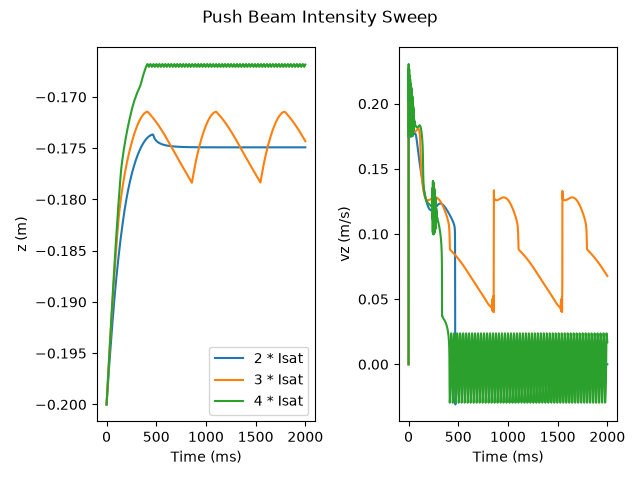

In [56]:
#Sweeping push beam intensity
intensityList = [2,3,4] # in units of Isat

fig, ax = plt.subplots(1,2, tight_layout = True)

for intensity in intensityList:
    laser_1.set_power_from_I(intensity * intercombination.Isat) # set power to reach Isat

    #------------------------------------------ config ------------------------------------------#
    config = Configuration()
    config.atom = atom
    config += laser_1, gravity, mag_field_3D_MOT, mag_field_2D_MOT
    config += las_z_up, las_z_down, las_x_plus, las_x_minus, las_y_plus, las_y_minus

    # Set a red-detuning relative to the intercombination transition
    detuning_push = -intercombination.Gamma  # red-detuning for pushing
    config.add_atomlight_coupling("las1", "intercombination", detuning_push) # Arguments: laser = "las1", transition = intercombination", detuning = detuning_push

    # Tie all 6 lasers to the intercombination transition simultaneously
    detuning_3D_mot = -2 * intercombination.Gamma
    for tag in ["z_up", "z_down", "x_plus", "x_minus", "y_plus", "y_minus"]:
        config.add_atomlight_coupling(tag, "intercombination", detuning_3D_mot)

    # - simulation
    sim = RK4(config=config)
    t = np.linspace(0, 2, 6000) # timesteps for integration
    u0 = (0, 0, -0.2, 0, 0, 0) # atom starts with z = -0.2 m (20 cm below the 3D MOT center) and zero velocity
    res= sim.integrate(u0, t)

    # ------------ Plotting
    ax[0].plot(res.t * 1e3, res.y[2], label=str(intensity) + " * Isat")
    ax[0].set_ylabel("z (m)")
    ax[0].set_xlabel("Time (ms)")
    ax[1].plot(res.t * 1e3, res.y[5], label=str(intensity) + " * Isat")
    ax[1].set_ylabel("vz (m/s)")
    ax[1].set_xlabel("Time (ms)")
ax[0].legend()
fig.suptitle("Push Beam Intensity Sweep")
plt.show()

Sweeping MOT beam intensity

In [61]:
# Fixed setup
#------------------------------------------ Atom setup ------------------------------------------#

atom = Ytterbium()
# get transition, to help setting up lasers
main = atom.trans["main"] # 399 nm transition to 1P1
intercombination = atom.trans["intercombination"] # 556 nm transition to 3P1

#------------------------------------------ Green push beam setup ------------------------------------------#

laser_1 = GaussianLaserBeam(
    wavelength=intercombination.wavelength,
    waist=5e-3,
    waist_position=(0, 0, -0.2),
    direction=(0, 0, 1),
)

laser_1.set_power_from_I(5 *intercombination.Isat) # set power to reach Isat
laser_1.polarization = Vertical()
laser_1.tag = "las1"

#------------------------------------------ 2D MOT B-field setup ------------------------------------------#

Br = 1.42  # Tesla
mu0 = 4*np.pi*1e-7
M = Br / mu0

magnet_1 = magpy.magnet.Cuboid(
    position = (-5.3*0.01, -4*0.01, 0), dimension = (2*0.01, 2*0.01, 5.5*0.01), magnetization = (0, 0, M))
magnet_2 = magpy.magnet.Cuboid(
    position = (-5.3*0.01, 4*0.01, 0), dimension = (2*0.01, 2*0.01, 5.5*0.01), magnetization = (0, 0, M))
magnet_3 = magpy.magnet.Cuboid(
    position = (5.3*0.01, -4*0.01, 0), dimension = (2*0.01, 2*0.01, 5.5*0.01), magnetization = (0, 0, -M))
magnet_4 = magpy.magnet.Cuboid(
    position = (5.3*0.01, 4*0.01, 0), dimension = (2*0.01, 2*0.01, 5.5*0.01), magnetization = (0, 0, -M))

magnets = magpy.Collection(magnet_1, magnet_2, magnet_3, magnet_4)

# Rotate so the extraction axis points UP (+z)
rot = R.from_euler('x', 90, degrees=True)
magnets.rotate(rot, anchor=(0, 0, 0))

# Shift the whole 2D MOT assembly 20 cm below the 3D MOT chamber center
magnets.move((0, 0, -0.2))

# wrap it up
mag_field_2D_MOT = MagpylibWrapper(magnets)
mag_field_2D_MOT.tag = "2D MOT coils"

#magnets.show(backend='plotly')

#------------------------------------------ 3D MOT B-field setup ------------------------------------------#

motcoil = mot3d_coil(config="AH", plot_obj=False)

# ROTATION: Rotate the 3D MOT coils if needed
# For example, rotating 90 degrees around the X-axis 
# (This would flip the coil symmetry axis from the Z-axis to the Y-axis)
rot_3d_mot = R.from_euler('x', 90, degrees=True)
motcoil.rotate(rot_3d_mot, anchor=(0, 0, 0))

# wrap it up
mag_field_3D_MOT = MagpylibWrapper(motcoil)
mag_field_3D_MOT.tag = "3D MOT coils"

#------------------------------------------ 3D MOT lasers setup ------------------------------------------#

# Create the 6 beams for a 3D MOT
# 1 & 2: Vertical Pair (+z, -z)
las_z_up = GaussianLaserBeam(wavelength=intercombination.wavelength, waist=7.5e-3, waist_position=(0, 0, 0), direction=(0,0,1))
las_z_down = GaussianLaserBeam(wavelength=intercombination.wavelength, waist=7.5e-3, waist_position=(0, 0, 0), direction=(0,0,-1))

# 3 & 4: Horizontal Pair 1 (+x, -x)
las_x_plus = GaussianLaserBeam(wavelength=intercombination.wavelength, waist=7.5e-3, waist_position=(0, 0, 0), direction=(1,0,0))
las_x_minus = GaussianLaserBeam(wavelength=intercombination.wavelength, waist=7.5e-3, waist_position=(0, 0, 0), direction=(-1,0,0))

# 5 & 6: Horizontal Pair 2 (+y, -y)
las_y_plus = GaussianLaserBeam(wavelength=intercombination.wavelength, waist=7.5e-3, waist_position=(0, 0, 0), direction=(0,1,0))
las_y_minus = GaussianLaserBeam(wavelength=intercombination.wavelength, waist=7.5e-3, waist_position=(0, 0, 0), direction=(0,-1,0))


# Assign Polarizations (Must be Circular and match the anti-Helmholtz field signs!)
las_z_up.polarization = CircularRight()
las_z_down.polarization = CircularRight()
las_x_plus.polarization = CircularRight()
las_x_minus.polarization = CircularRight()
las_y_plus.polarization = CircularLeft()
las_y_minus.polarization = CircularLeft()

# Tag them for coupling identification
las_z_up.tag = "z_up"; las_z_down.tag = "z_down"
las_x_plus.tag = "x_plus"; las_x_minus.tag = "x_minus"
las_y_plus.tag = "y_plus"; las_y_minus.tag = "y_minus"

#------------------------------------------ Gravity ------------------------------------------#

m = Ytterbium().mass  # kg
g = 9.81  # m/s^2
grav_force = (0, 0, -m*g)
gravity = ConstantForce(field_value=grav_force, tag="gravity")




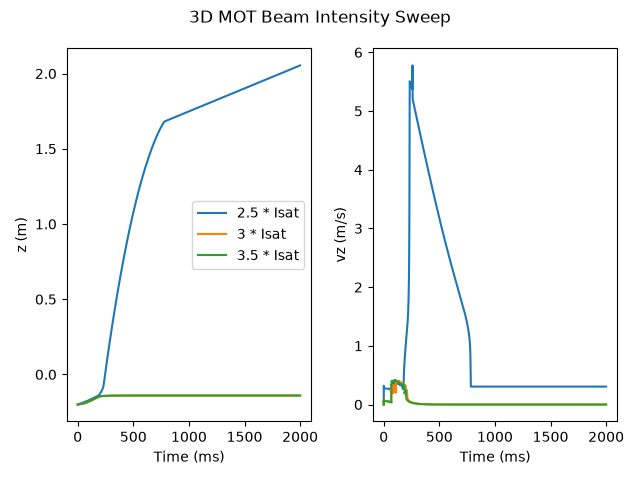

In [64]:

#Sweeping MOT beam intensity
intensityList = [2.5,3,3.5] # in units of Isat

fig, ax = plt.subplots(1,2, tight_layout = True)

for intensity in intensityList:
    # Set power (can increase if we want power broadening)
    las_z_up.set_power_from_I(intensity * intercombination.Isat)
    las_z_down.set_power_from_I(intensity * intercombination.Isat)
    las_x_plus.set_power_from_I(intensity * intercombination.Isat)
    las_x_minus.set_power_from_I(intensity * intercombination.Isat)
    las_y_plus.set_power_from_I(intensity * intercombination.Isat)
    las_y_minus.set_power_from_I(intensity * intercombination.Isat)

    #------------------------------------------ config ------------------------------------------#
    config = Configuration()
    config.atom = atom
    config += laser_1, gravity, mag_field_3D_MOT, mag_field_2D_MOT
    config += las_z_up, las_z_down, las_x_plus, las_x_minus, las_y_plus, las_y_minus

    # Set a red-detuning relative to the intercombination transition
    detuning_push = 0  # red-detuning for pushing
    config.add_atomlight_coupling("las1", "intercombination", detuning_push) # Arguments: laser = "las1", transition = intercombination", detuning = detuning_push

    # Tie all 6 lasers to the intercombination transition simultaneously
    detuning_3D_mot = -5 * intercombination.Gamma
    for tag in ["z_up", "z_down", "x_plus", "x_minus", "y_plus", "y_minus"]:
        config.add_atomlight_coupling(tag, "intercombination", detuning_3D_mot)

    # - simulation
    sim = RK4(config=config)
    t = np.linspace(0, 2, 6000) # timesteps for integration
    u0 = (0, 0, -0.2, 0, 0, 0) # atom starts with z = -0.2 m (20 cm below the 3D MOT center) and zero velocity
    res= sim.integrate(u0, t)

    # ------------ Plotting
    ax[0].plot(res.t * 1e3, res.y[2], label=str(intensity) + " * Isat")
    ax[0].set_ylabel("z (m)")
    ax[0].set_xlabel("Time (ms)")
    ax[1].plot(res.t * 1e3, res.y[5], label=str(intensity) + " * Isat")
    ax[1].set_ylabel("vz (m/s)")
    ax[1].set_xlabel("Time (ms)")
ax[0].legend()
fig.suptitle("3D MOT Beam Intensity Sweep")
plt.show()

In [65]:
path = "C:\\Users\\zhang\\Documents\\GitHub\\YbIII\\Vertical_2Dto3DMOT_Loading_Figures"
fig.savefig(path + "\\Trial8.png", dpi=300)

1143539.7259066848
